# drive mont

In [14]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import pandas as pd

path = '/content/drive/MyDrive/Ridewise-data/'

hour_df = pd.read_csv(path + 'hour.csv')
day_df = pd.read_csv(path + 'day.csv')


**Week 1: Project Initialization and Dataset Acquisition.**


# **DATA**  & Explore the structure and quality of each datase


In [16]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt




In [19]:
import pandas as pd

path = '/content/drive/MyDrive/Ridewise-data/'

hour_df = pd.read_csv(path + 'hour.csv')
day_df = pd.read_csv(path + 'day.csv')


In [20]:
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [21]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [22]:
print("Hour dataset shape:", hour_df.shape)
print("Day dataset shape:", day_df.shape)

Hour dataset shape: (17379, 17)
Day dataset shape: (731, 16)


In [23]:
print("===== MISSING VALUES: HOUR DATA =====")
print(hour_df.isnull().sum())

print("\n===== MISSING VALUES: DAY DATA =====")
print(day_df.isnull().sum())

===== MISSING VALUES: HOUR DATA =====
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

===== MISSING VALUES: DAY DATA =====
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [24]:
print("===== DATA TYPES: HOUR DATA =====")
print(hour_df.dtypes)

print("\n===== DATA TYPES: DAY DATA =====")
print(day_df.dtypes)


===== DATA TYPES: HOUR DATA =====
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

===== DATA TYPES: DAY DATA =====
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


In [25]:
print("\n===== COLUMNS: HOUR DATA =====")
print(hour_df.columns)

print("\n===== COLUMNS: DAY DATA =====")
print(day_df.columns)


===== COLUMNS: HOUR DATA =====
Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

===== COLUMNS: DAY DATA =====
Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')


# **week2 Data Preprocessing and Feature Selection**

**Data Cleaning and Preprocessing of Hourly Bike-Sharing Dataset**

In [34]:
import pandas as pd
import numpy as np
path = "/content/drive/MyDrive/Ridewise-data/"
df = pd.read_csv(path + "hour.csv")
df.drop(["instant", "casual", "registered"], axis=1, inplace=True)  # Removing rhe leakage & irrelevant columns.
df["dteday"] = pd.to_datetime(df["dteday"])
df.drop_duplicates(inplace=True) #Remove duplicates
cat_cols = ["season", "yr", "mnth", "hr", "holiday", "weekday", "workingday", "weathersit"]
df[cat_cols] = df[cat_cols].astype(int)
df = df.ffill()


#  TIME FEATURES
df["year"] = df["yr"]
df["month"] = df["dteday"].dt.month
df["day"] = df["dteday"].dt.day
df["weekday"] = df["dteday"].dt.weekday
df["is_weekend"] = df["weekday"].isin([5, 6]).astype(int)
df["week_of_year"] = df["dteday"].dt.isocalendar().week.astype(int)

# CYCLIC
df["hour_sin"] = np.sin(2 * np.pi * df["hr"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hr"] / 24)

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

#WEATHER FEATURES
df["temp_level"] = pd.cut(
    df["temp"],
    bins=[0, 0.33, 0.66, 1],
    labels=["Low", "Medium", "High"]
)

df["humid_flag"] = (df["hum"] > df["hum"].mean()).astype(int)
df["windy_flag"] = (df["windspeed"] > df["windspeed"].mean()).astype(int)

df["weather_severity"] = (
    (df["temp"] * 0.4) +
    (df["hum"] * 0.3) +
    (df["windspeed"] * 0.3)
)

df["storm_flag"] = (df["weathersit"] >= 3).astype(int)

#EVENT FEATURES
df["is_holiday"] = df["holiday"]
df["is_working_day"] = df["workingday"]
df["event_day"] = ((df["holiday"] == 1) | (df["workingday"] == 0)).astype(int)

#  LAG FEATURES
df["cnt_lag_1"] = df["cnt"].shift(1)
df["cnt_lag_24"] = df["cnt"].shift(24)

# Rolling average
df["cnt_rolling_24"] = df["cnt"].rolling(window=24).mean()

# Remove NaNs created by lag/rolling
df = df.dropna().reset_index(drop=True)

#  FINAL CLEANUP
df.drop(["dteday", "year"], axis=1, inplace=True)

print("Final dataset shape after preprocessing:", df.shape)
df.head()

print("------------------------------------------------------")
print("✔ Preprocessing Completed Successfully")
print("✔ No errors encountered")
print("✔ Final dataset shape:", df.shape)
print("✔ Columns:", len(df.columns))
print("------------------------------------------------------")

print("\n SAMPLE ROWS AFTER PREPROCESSING:")
display(df.head())

print("\n SUMMARY STATISTICS:")
display(df.describe())

print("\n NULL VALUES CHECK:")
print(df.isnull().sum())



Final dataset shape after preprocessing: (17355, 32)
------------------------------------------------------
✔ Preprocessing Completed Successfully
✔ No errors encountered
✔ Final dataset shape: (17355, 32)
✔ Columns: 32
------------------------------------------------------

 SAMPLE ROWS AFTER PREPROCESSING:


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,...,humid_flag,windy_flag,weather_severity,storm_flag,is_holiday,is_working_day,event_day,cnt_lag_1,cnt_lag_24,cnt_rolling_24
0,1,0,1,0,0,6,0,2,0.46,0.4545,...,1,1,0.53755,0,0,0,1,39.0,16.0,41.083333
1,1,0,1,1,0,6,0,2,0.44,0.4394,...,1,1,0.53411,0,0,0,1,17.0,40.0,40.125000
2,1,0,1,2,0,6,0,2,0.42,0.4242,...,1,1,0.55308,0,0,0,1,17.0,32.0,39.166667
3,1,0,1,3,0,6,0,2,0.46,0.4545,...,1,1,0.52420,0,0,0,1,9.0,13.0,38.875000
4,1,0,1,4,0,6,0,2,0.46,0.4545,...,1,1,0.52420,0,0,0,1,6.0,1.0,38.958333



 SUMMARY STATISTICS:


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,...,humid_flag,windy_flag,weather_severity,storm_flag,is_holiday,is_working_day,event_day,cnt_lag_1,cnt_lag_24,cnt_rolling_24
count,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,...,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000,17355.000000
mean,2.503717,0.503256,6.545434,11.546816,0.028810,3.008701,0.683665,1.425065,0.497199,0.475930,...,0.502103,0.501873,0.444016,0.081821,0.028810,0.683665,0.316335,189.667761,189.567848,189.611822
std,1.106273,0.500004,3.434976,6.914394,0.167277,2.001983,0.465059,0.639329,0.192573,0.171897,...,0.500010,0.500011,0.092981,0.274099,0.167277,0.465059,0.465059,181.425094,181.462851,78.941873
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,...,0.000000,0.000000,0.132000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,18.041667
25%,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,...,0.000000,0.000000,0.373040,0.000000,0.000000,0.000000,0.000000,40.000000,40.000000,133.250000
50%,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,...,1.000000,1.000000,0.454170,0.000000,0.000000,1.000000,0.000000,142.000000,142.000000,189.666667
75%,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,...,1.000000,1.000000,0.518880,0.000000,0.000000,1.000000,1.000000,281.000000,281.000000,248.395833
max,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,...,1.000000,1.000000,0.773740,1.000000,1.000000,1.000000,1.000000,977.000000,977.000000,382.500000



 NULL VALUES CHECK:
season              0
yr                  0
mnth                0
hr                  0
holiday             0
weekday             0
workingday          0
weathersit          0
temp                0
atemp               0
hum                 0
windspeed           0
cnt                 0
month               0
day                 0
is_weekend          0
week_of_year        0
hour_sin            0
hour_cos            0
month_sin           0
month_cos           0
temp_level          0
humid_flag          0
windy_flag          0
weather_severity    0
storm_flag          0
is_holiday          0
is_working_day      0
event_day           0
cnt_lag_1           0
cnt_lag_24          0
cnt_rolling_24      0
dtype: int64


# Correlation Heatmap Showing Relationships Between Weather, Time, and Demand Features



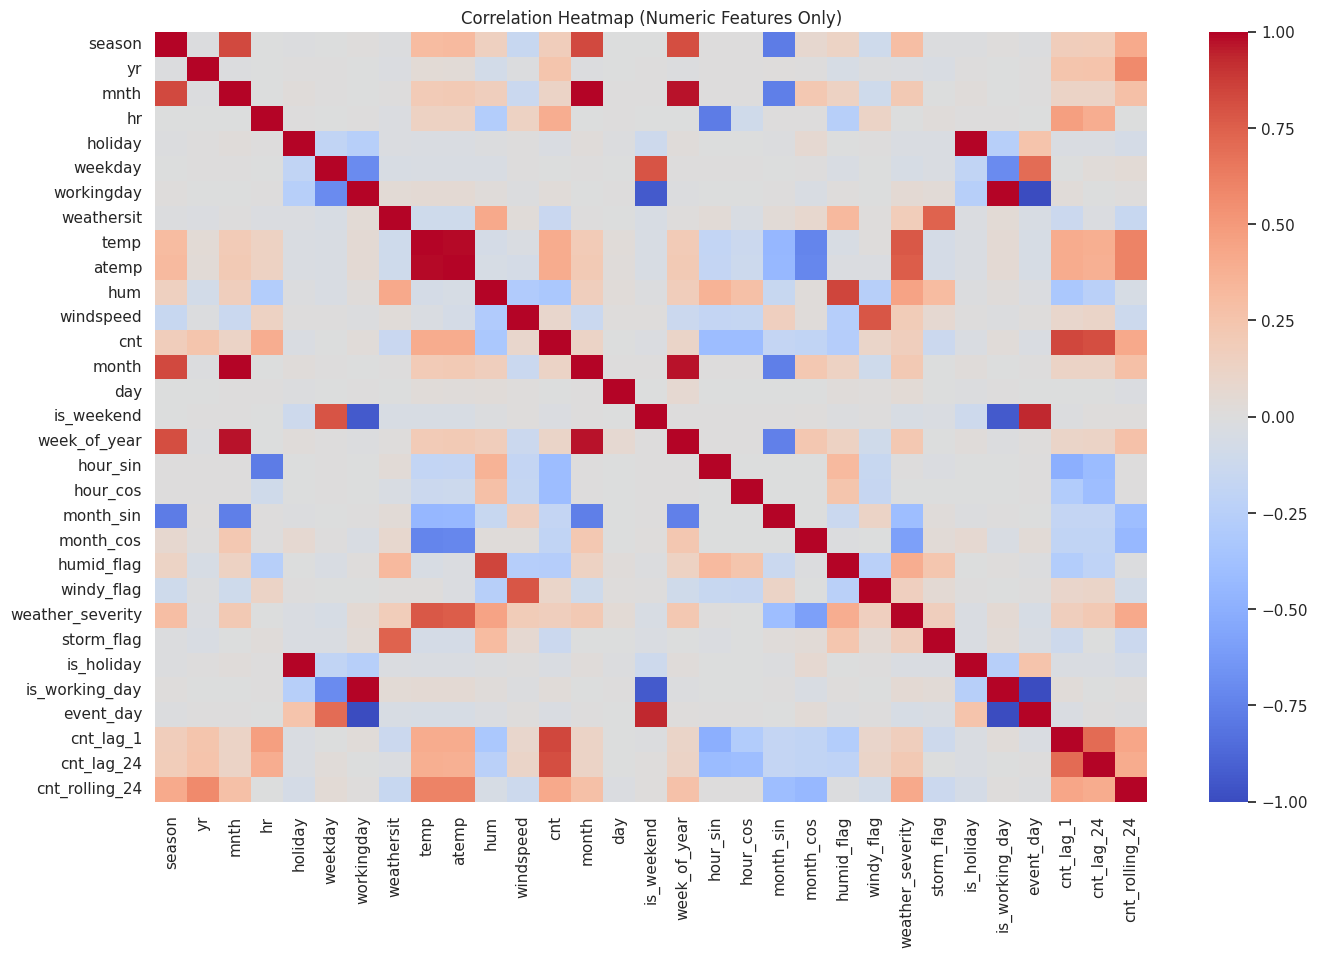

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(16, 10))
corr = numeric_df.corr()
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()



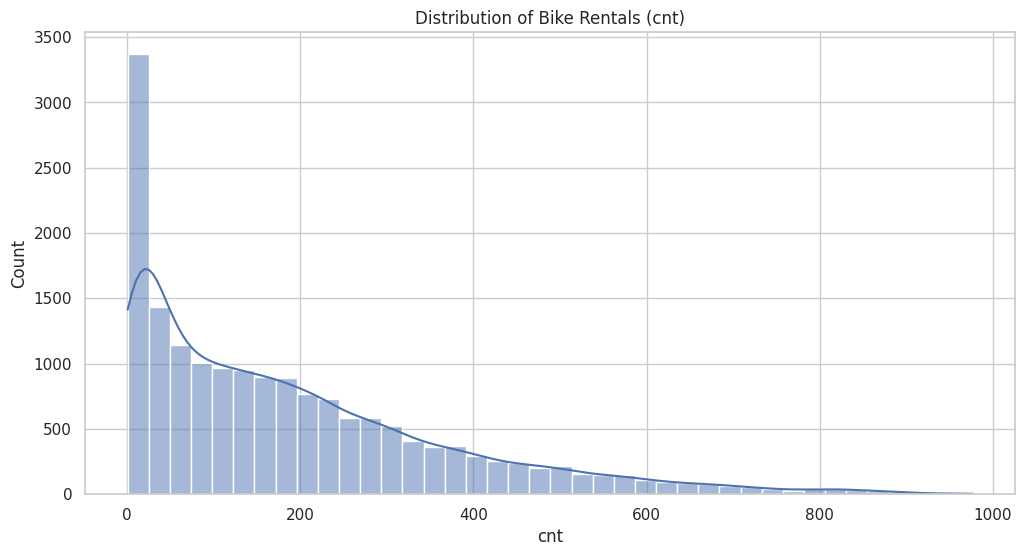

In [40]:
sns.histplot(df['cnt'], bins=40, kde=True)
plt.title("Distribution of Bike Rentals (cnt)")
plt.show()


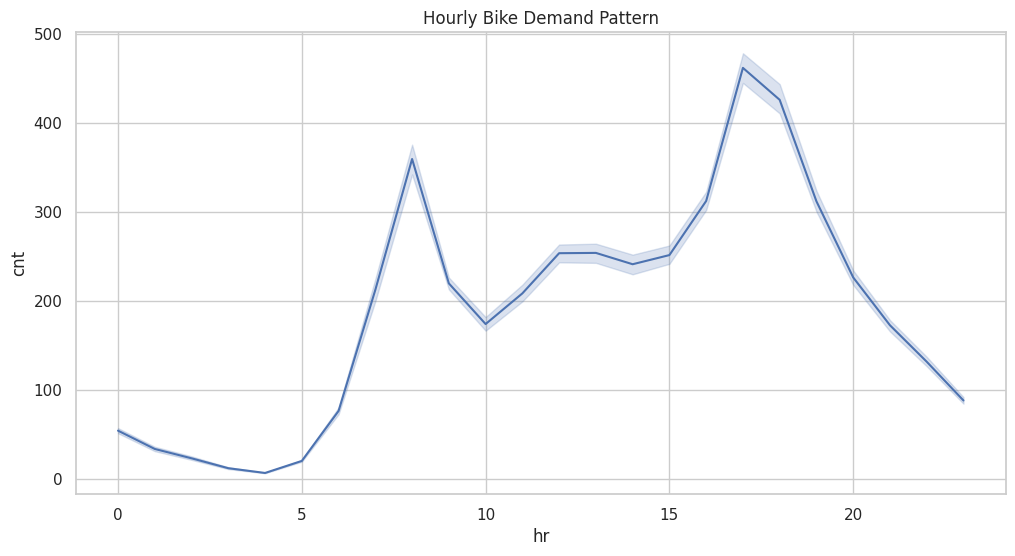

In [41]:
sns.lineplot(x="hr", y="cnt", data=df)
plt.title("Hourly Bike Demand Pattern")
plt.show()


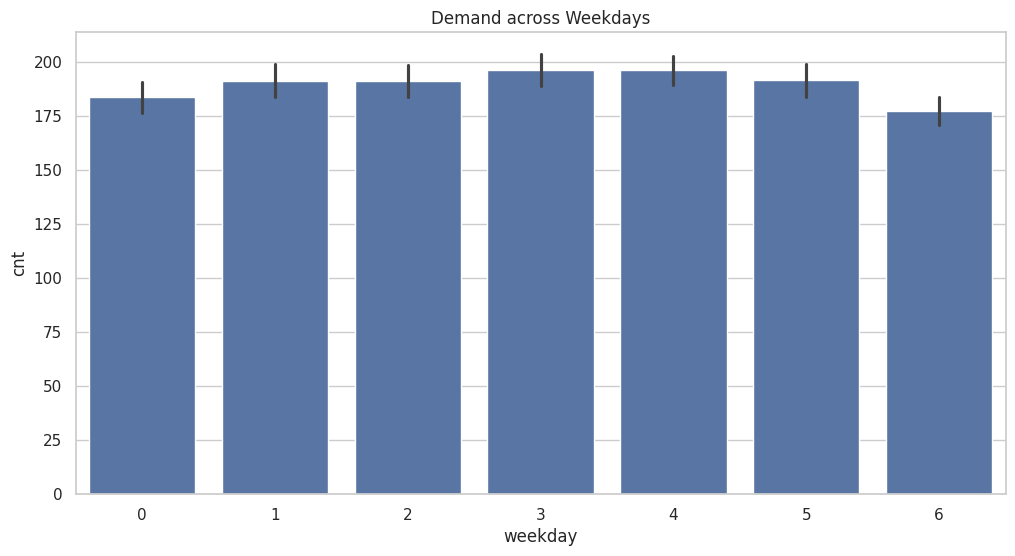

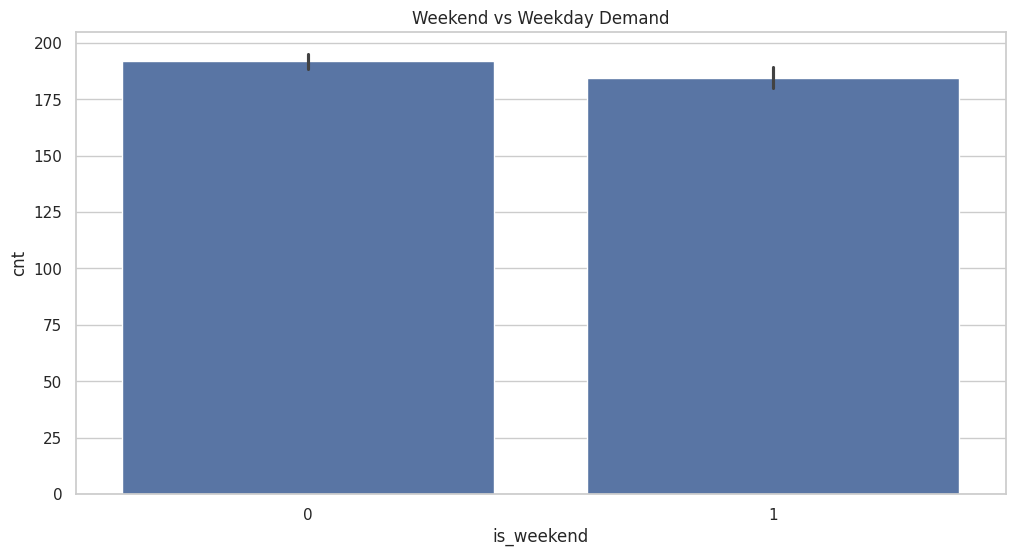

In [42]:
sns.barplot(x="weekday", y="cnt", data=df)
plt.title("Demand across Weekdays")
plt.show()

sns.barplot(x="is_weekend", y="cnt", data=df)
plt.title("Weekend vs Weekday Demand")
plt.show()


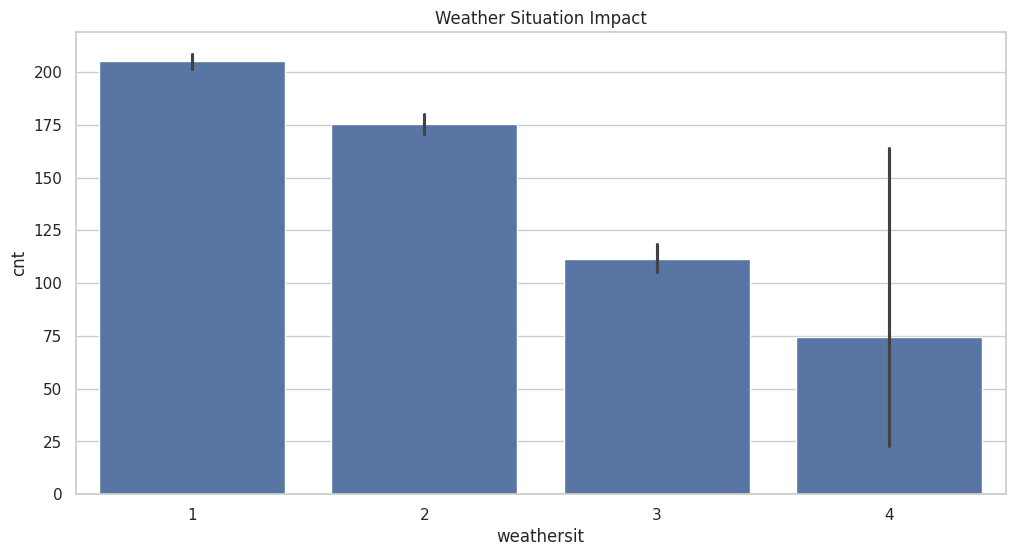

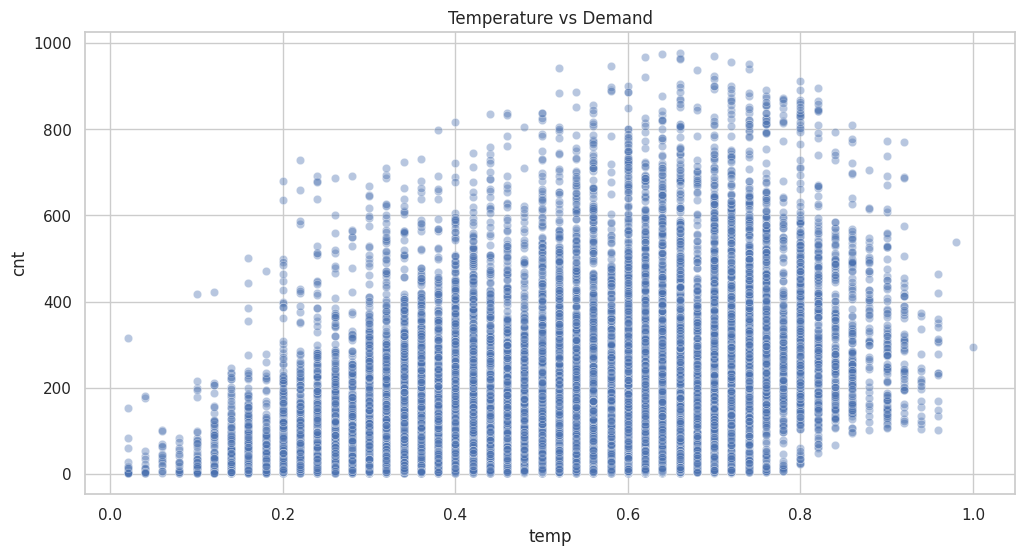

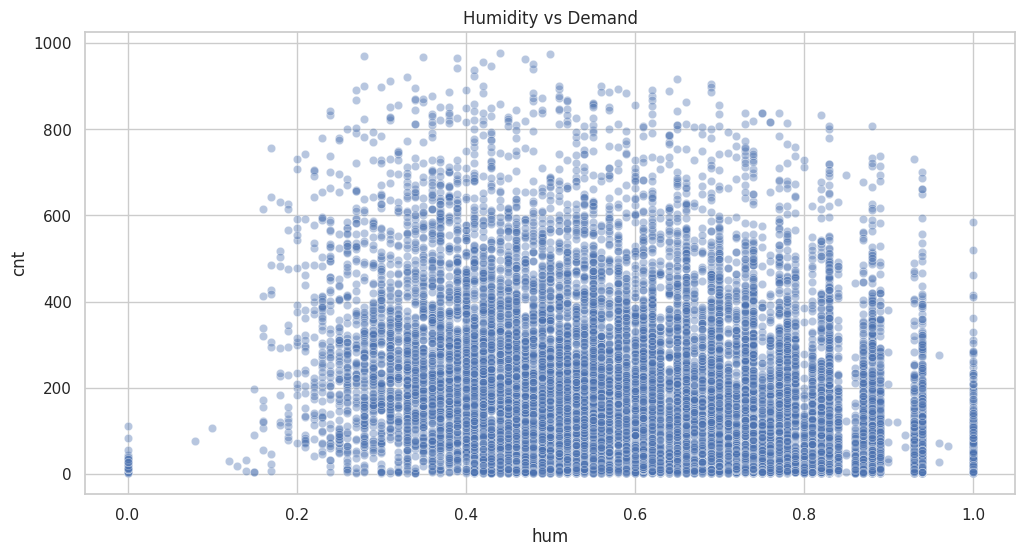

In [43]:
sns.barplot(x="weathersit", y="cnt", data=df)
plt.title("Weather Situation Impact")
plt.show()

sns.scatterplot(x="temp", y="cnt", alpha=0.4, data=df)
plt.title("Temperature vs Demand")
plt.show()

sns.scatterplot(x="hum", y="cnt", alpha=0.4, data=df)
plt.title("Humidity vs Demand")
plt.show()


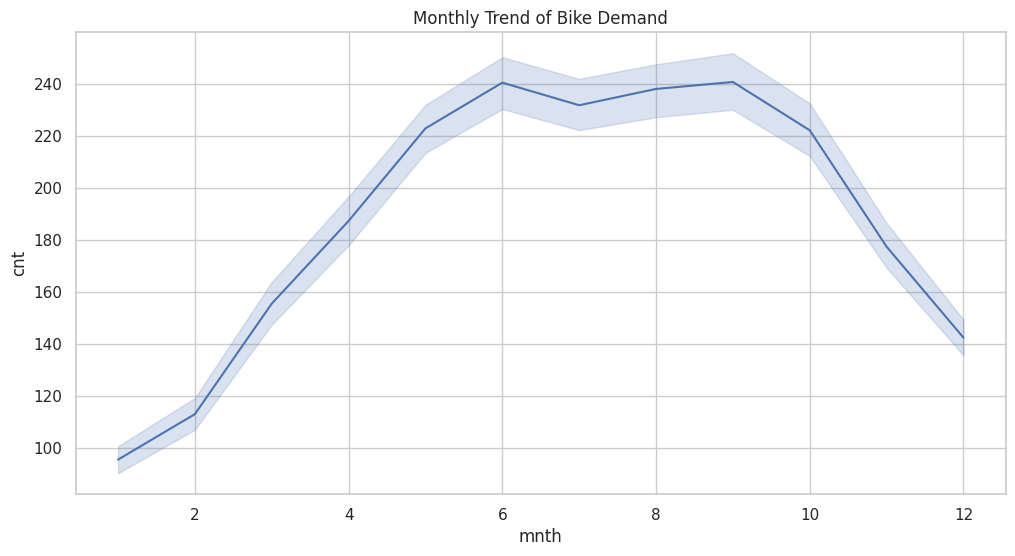

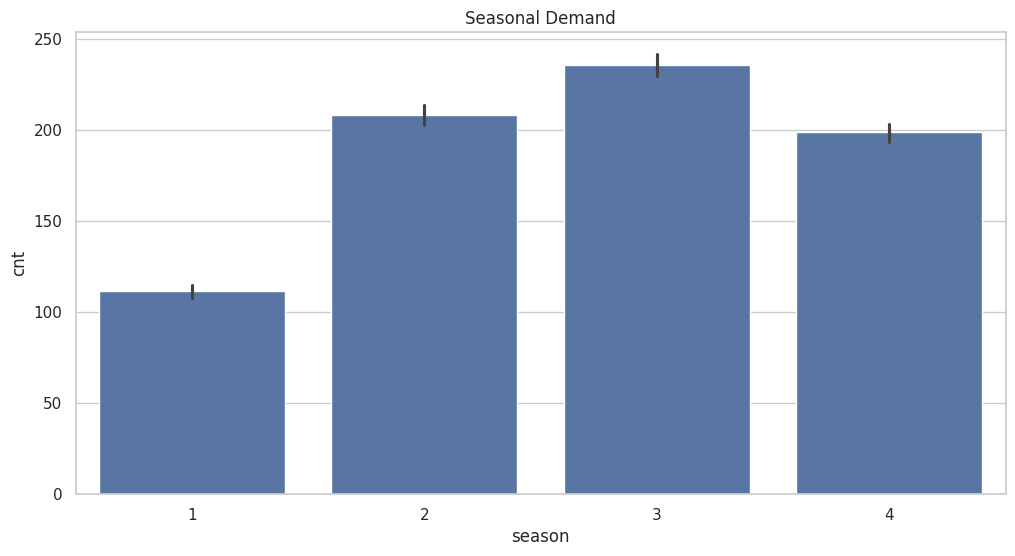

In [44]:
sns.lineplot(x="mnth", y="cnt", data=df)
plt.title("Monthly Trend of Bike Demand")
plt.show()

sns.barplot(x="season", y="cnt", data=df)
plt.title("Seasonal Demand")
plt.show()


In [46]:
drop_cols = ["instant", "dteday", "yr", "casual", "registered"]
existing_drop_cols = [col for col in drop_cols if col in df.columns]
df.drop(existing_drop_cols, axis=1, inplace=True)
print("-----------------------------------------------------")
print(" Columns dropped:", existing_drop_cols)
print(" Number of columns dropped:", len(existing_drop_cols))
print("-----------------------------------------------------")

print("\n Remaining Columns (After Dropping):")
print(list(df.columns))
print("\nTotal Remaining Columns:", len(df.columns))

print("\nFinal Dataset Shape:", df.shape)


-----------------------------------------------------
 Columns dropped: []
 Number of columns dropped: 0
-----------------------------------------------------

 Remaining Columns (After Dropping):
['season', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt', 'month', 'day', 'is_weekend', 'week_of_year', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'temp_level', 'humid_flag', 'windy_flag', 'weather_severity', 'storm_flag', 'is_holiday', 'is_working_day', 'event_day', 'cnt_lag_1', 'cnt_lag_24', 'cnt_rolling_24']

Total Remaining Columns: 31

Final Dataset Shape: (17355, 31)


In [48]:
df.head()

,season,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,...,humid_flag,windy_flag,weather_severity,storm_flag,is_holiday,is_working_day,event_day,cnt_lag_1,cnt_lag_24,cnt_rolling_24
0,1,1,0,0,6,0,2,0.46,0.4545,0.88,...,1,1,0.53755,0,0,0,1,39.0,16.0,41.083333
1,1,1,1,0,6,0,2,0.44,0.4394,0.94,...,1,1,0.53411,0,0,0,1,17.0,40.0,40.125000
2,1,1,2,0,6,0,2,0.42,0.4242,1.00,...,1,1,0.55308,0,0,0,1,17.0,32.0,39.166667
3,1,1,3,0,6,0,2,0.46,0.4545,0.94,...,1,1,0.52420,0,0,0,1,9.0,13.0,38.875000
4,1,1,4,0,6,0,2,0.46,0.4545,0.94,...,1,1,0.52420,0,0,0,1,6.0,1.0,38.958333
